In [1]:
# ruff: noqa: F405
%cd /lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/demo

from _shared import pl_k_sP, psc_ds, run_deg_groups, run_nmf, run_proc_per_ds, viz_defs, comp_spat_stats  # isort:skip

from functools import partial
from pathlib import Path
from pickle import dump, load
from warnings import catch_warnings, simplefilter

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import uapl
import upsetplot as up
from matplotlib import pyplot as plt
from plotnine import *  # noqa: F403

import spatialpeeler as sP
from spatialpeeler.diag import comp_sparsity, sweep_uns

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/demo


/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
viz_defs(dpi=128)
RAND_SEED = 28
# define helper function for plotting
pl_help = partial(pl_k_sP, cond_col="group", sample_col="sample_id", ctl_val="CTL")
SP_FACT_PAT_STR = "sP_p_hat_k={k}"
SP_GENE_PAT_STR = "sp_gene_id_k={k}"

# fill in after inspecting the beta/spatial stats plots
CASE_KS = [8, 6, 29, 4, 27, 21, 32, 10, 38, 13, 24, 12]
CTL_KS = [25, 30, 16, 17, 5, 26, 20, 22, 2, 33, 9, 18]

In [3]:
# load dataset + run NMF
if (pth := Path("../.cache/psc_k50.pkl")).exists():
    with open(pth, "rb") as f:
        psc = load(f)
else:
    # start from k=30 cache (same processed data) and re-run NMF with k=50
    with open(Path("../.cache/psc.pkl"), "rb") as f:
        psc = load(f)

    # drop k=30 NMF results so we start clean
    for key in list(psc.obsm.keys()) + list(psc.uns.keys()):
        if "nmf" in key.lower() or "sP_" in key or "sp_gene" in key:
            psc.obsm.pop(key, None)
            psc.uns.pop(key, None)
    psc.varm.pop("X_nmf", None)

    run_nmf(psc, 50, RAND_SEED)

    pth.parent.mkdir(exist_ok=True)
    with open(pth, "wb") as f:
        dump(psc, f)
print(psc)

AnnData object with n_obs × n_vars = 21553 × 16465
    obs: 'in_tissue', 'percent.mt', 'cell_type', 'group', 'sample_id'
    var: 'n_cells', 'SYMBOL'
    obsm: 'spatial', 'X_nmf'
    varm: 'X_nmf'
    layers: 'counts'


with our processed data, we proceed with the factor-wise regression step of spatialPeeler

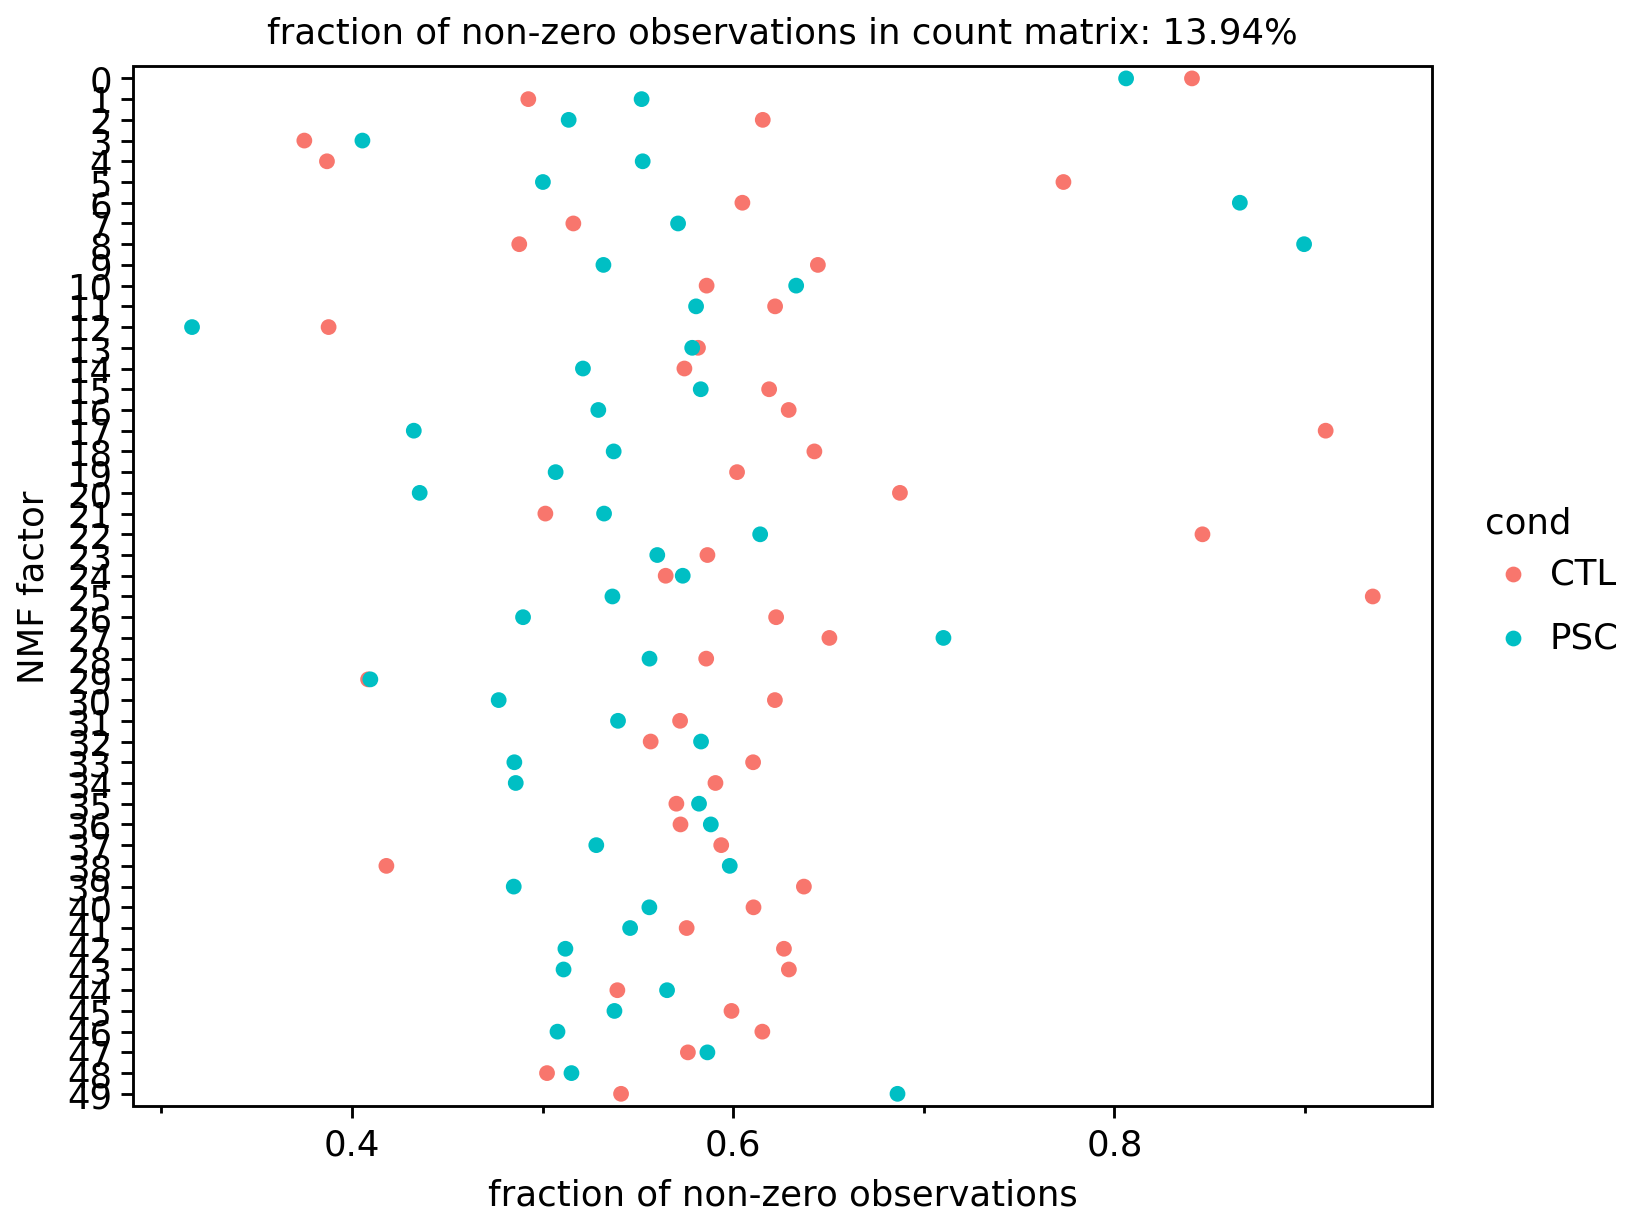

In [7]:
X_spars = psc.X.nnz / np.prod(psc.X.shape)  # ty:ignore[unresolved-attribute]
(
    comp_sparsity(psc.obsm["X_nmf"], cond=psc.obs["group"])
    >> ggplot()
    + aes(x="density", y="column", color="cond")
    + geom_point()
    + scale_y_discrete(limits=reversed)  # ty:ignore[invalid-argument-type]
    + labs(
        x="fraction of non-zero observations",
        y="NMF factor",
        title=f"fraction of non-zero observations in count matrix: {X_spars * 100:.02f}%",
    )
).show()

In [8]:
# run factor-wise regression step
for k in range(psc.obsm["X_nmf"].shape[1]):
    sP.run_fact_reg(psc, "group", "CTL", k, SP_FACT_PAT_STR.format(k=k), X_key="X_nmf")

print(psc)

AnnData object with n_obs × n_vars = 21553 × 16465
    obs: 'in_tissue', 'percent.mt', 'cell_type', 'group', 'sample_id'
    var: 'n_cells', 'SYMBOL'
    uns: 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_p_hat_k=16', 'sP_p_hat_k=17', 'sP_p_hat_k=18', 'sP_p_hat_k=19', 'sP_p_hat_k=20', 'sP_p_hat_k=21', 'sP_p_hat_k=22', 'sP_p_hat_k=23', 'sP_p_hat_k=24', 'sP_p_hat_k=25', 'sP_p_hat_k=26', 'sP_p_hat_k=27', 'sP_p_hat_k=28', 'sP_p_hat_k=29', 'sP_p_hat_k=30', 'sP_p_hat_k=31', 'sP_p_hat_k=32', 'sP_p_hat_k=33', 'sP_p_hat_k=34', 'sP_p_hat_k=35', 'sP_p_hat_k=36', 'sP_p_hat_k=37', 'sP_p_hat_k=38', 'sP_p_hat_k=39', 'sP_p_hat_k=40', 'sP_p_hat_k=41', 'sP_p_hat_k=42', 'sP_p_hat_k=43', 'sP_p_hat_k=44', 'sP_p_hat_k=45', 'sP_p_hat_k=46', 'sP_p_hat_k=47', 'sP_p_hat_k=48', 'sP_p_hat_k=49'
  

we now assess our resulting regression outputs distributions \
we can extract and collate the model betas and other statistics using the sweep_uns function

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log


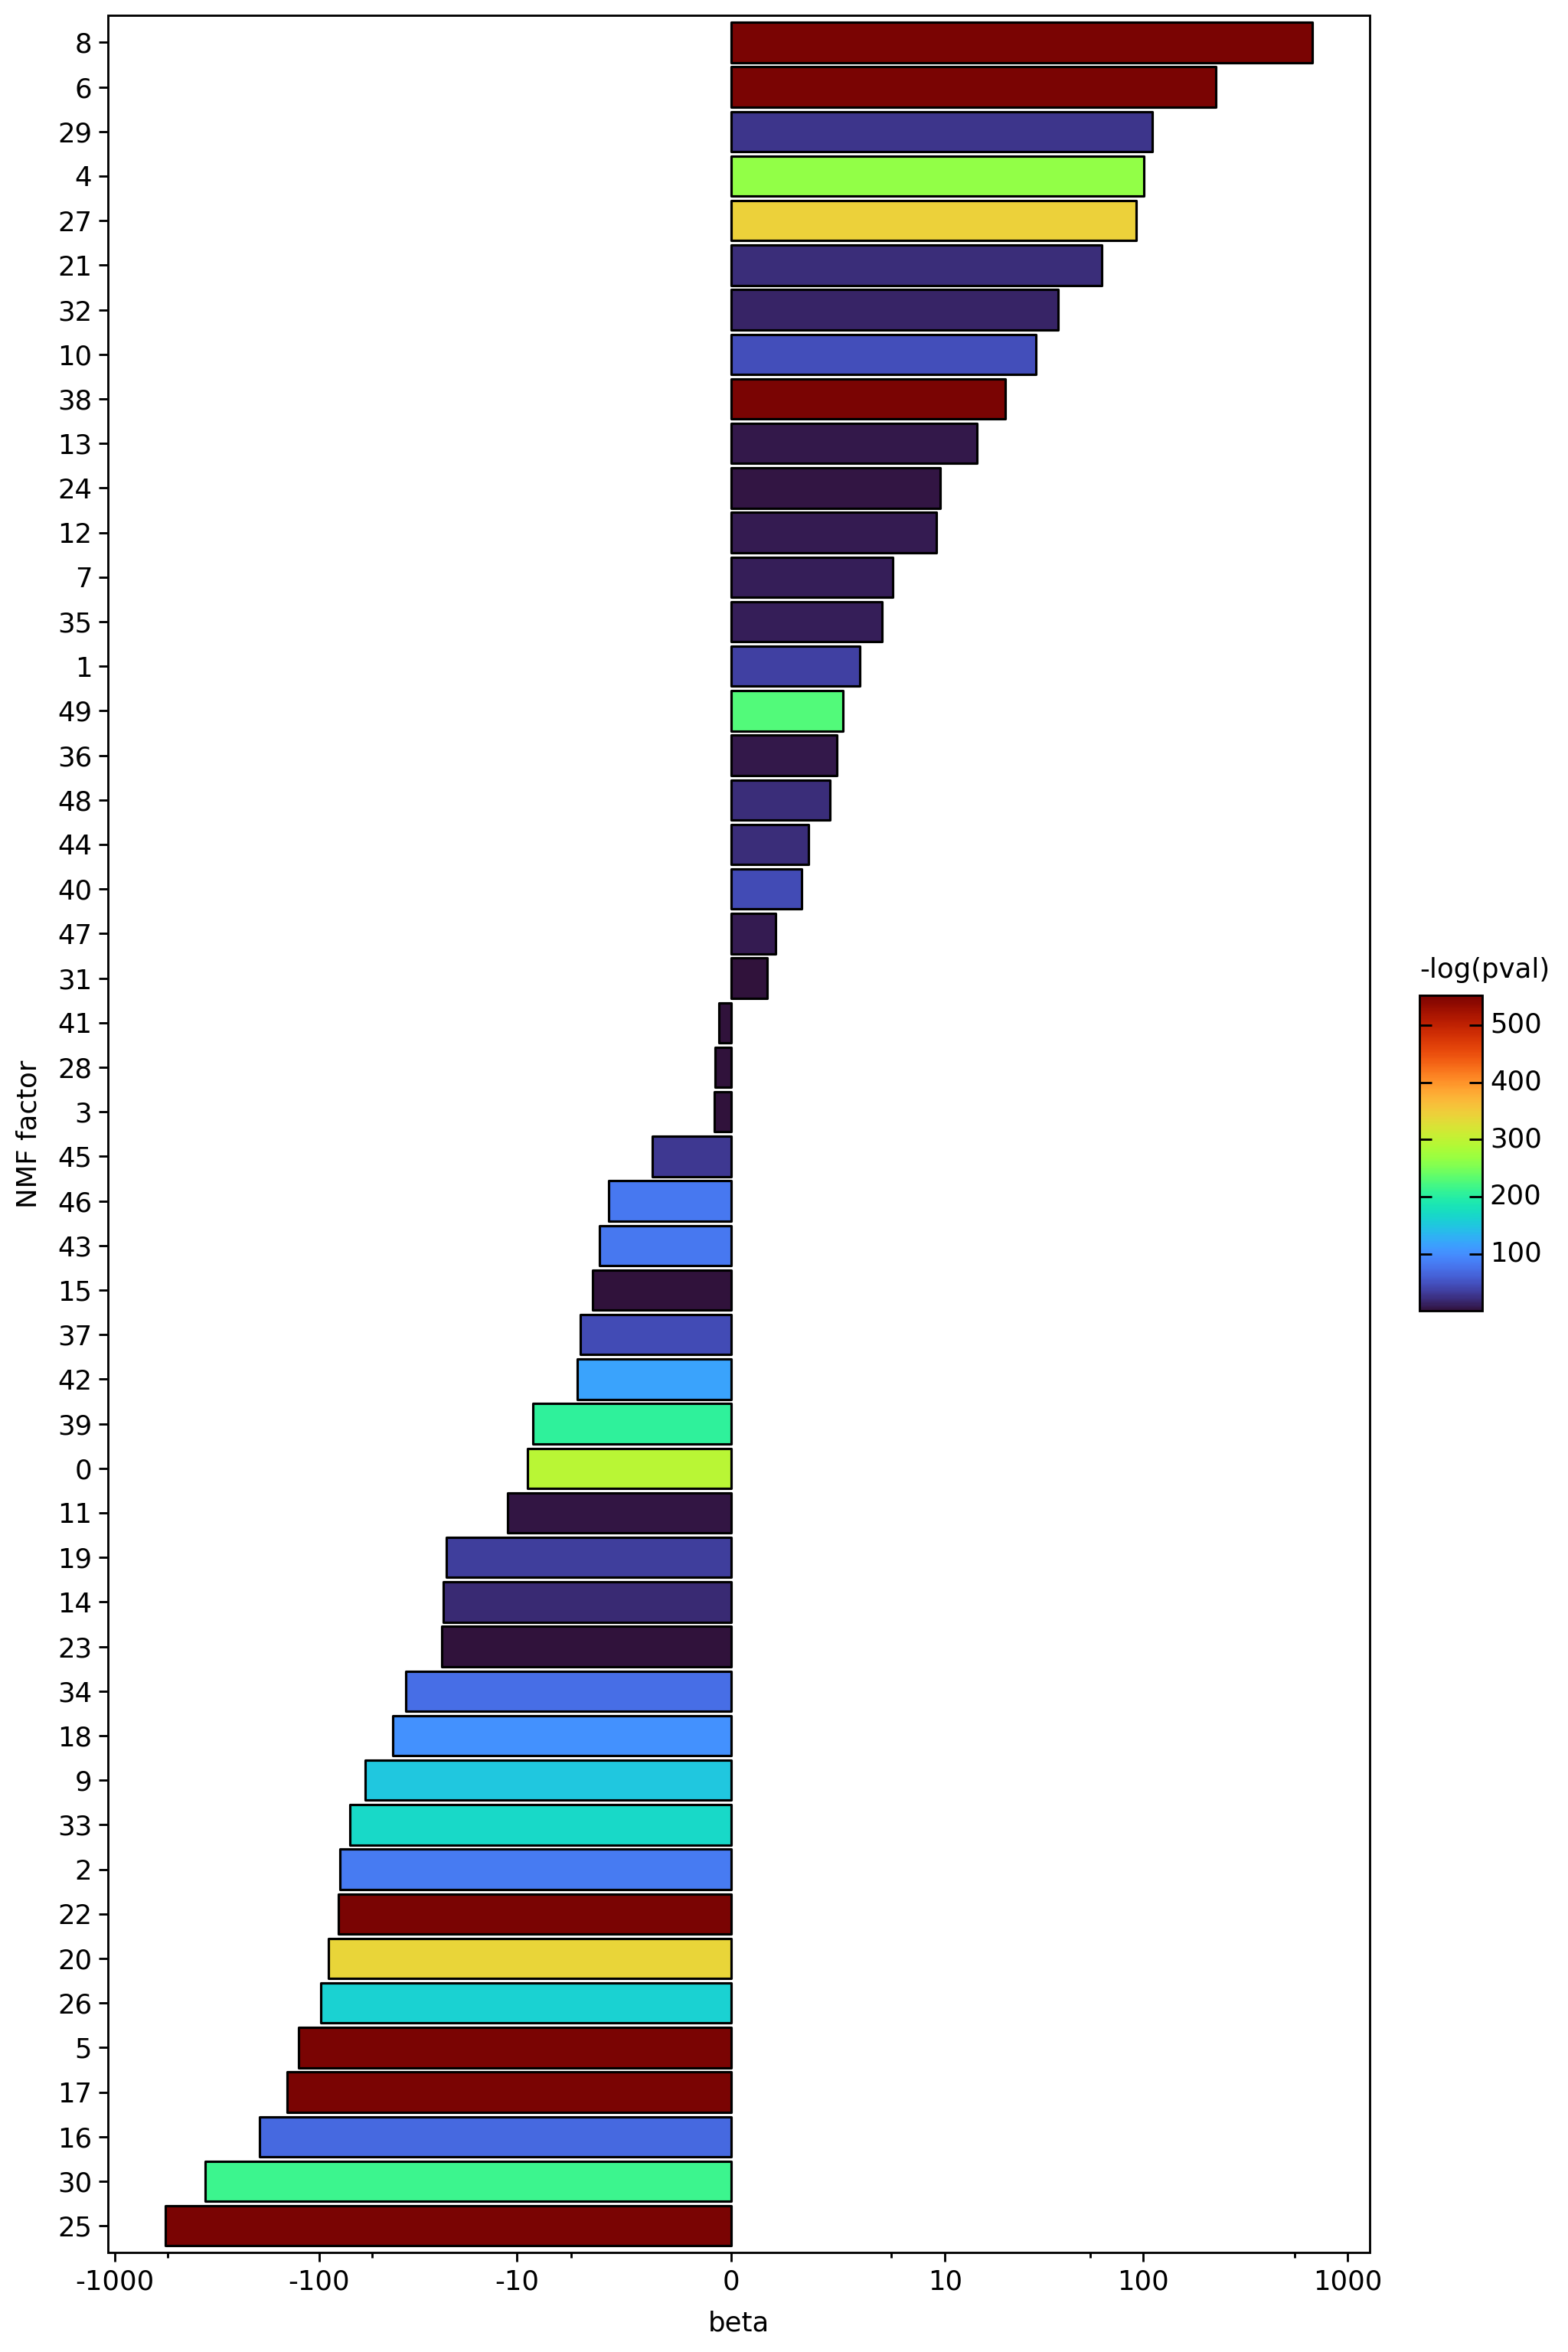

In [ ]:
(
    sweep_uns(psc, SP_FACT_PAT_STR)
    >> ggplot()
    + aes(x="reorder(k, beta)", fill="-np.log(pval)", y="beta")
    + geom_col(color="black")
    + coord_flip()
    + labs(fill="-log(pval)", x="NMF factor")
    + scale_fill_cmap("turbo")
    + scale_y_symlog()
    + theme(figure_size=(8, 12))
).show()

to explore the spatial properties of the resulting factor patterns, we can compute and plot
spatial statistics for each on a per sample basis (in this case Geary's C and Morans' I):

In [ ]:

psc.raw = None  # drop raw to avoid copying the full sparse matrix on every AnnData slice in comp_spat_stats

In [7]:
sp_stat_df, sp_stat_pl = comp_spat_stats(psc, SP_FACT_PAT_STR, "sample_id", "group", "CTL")

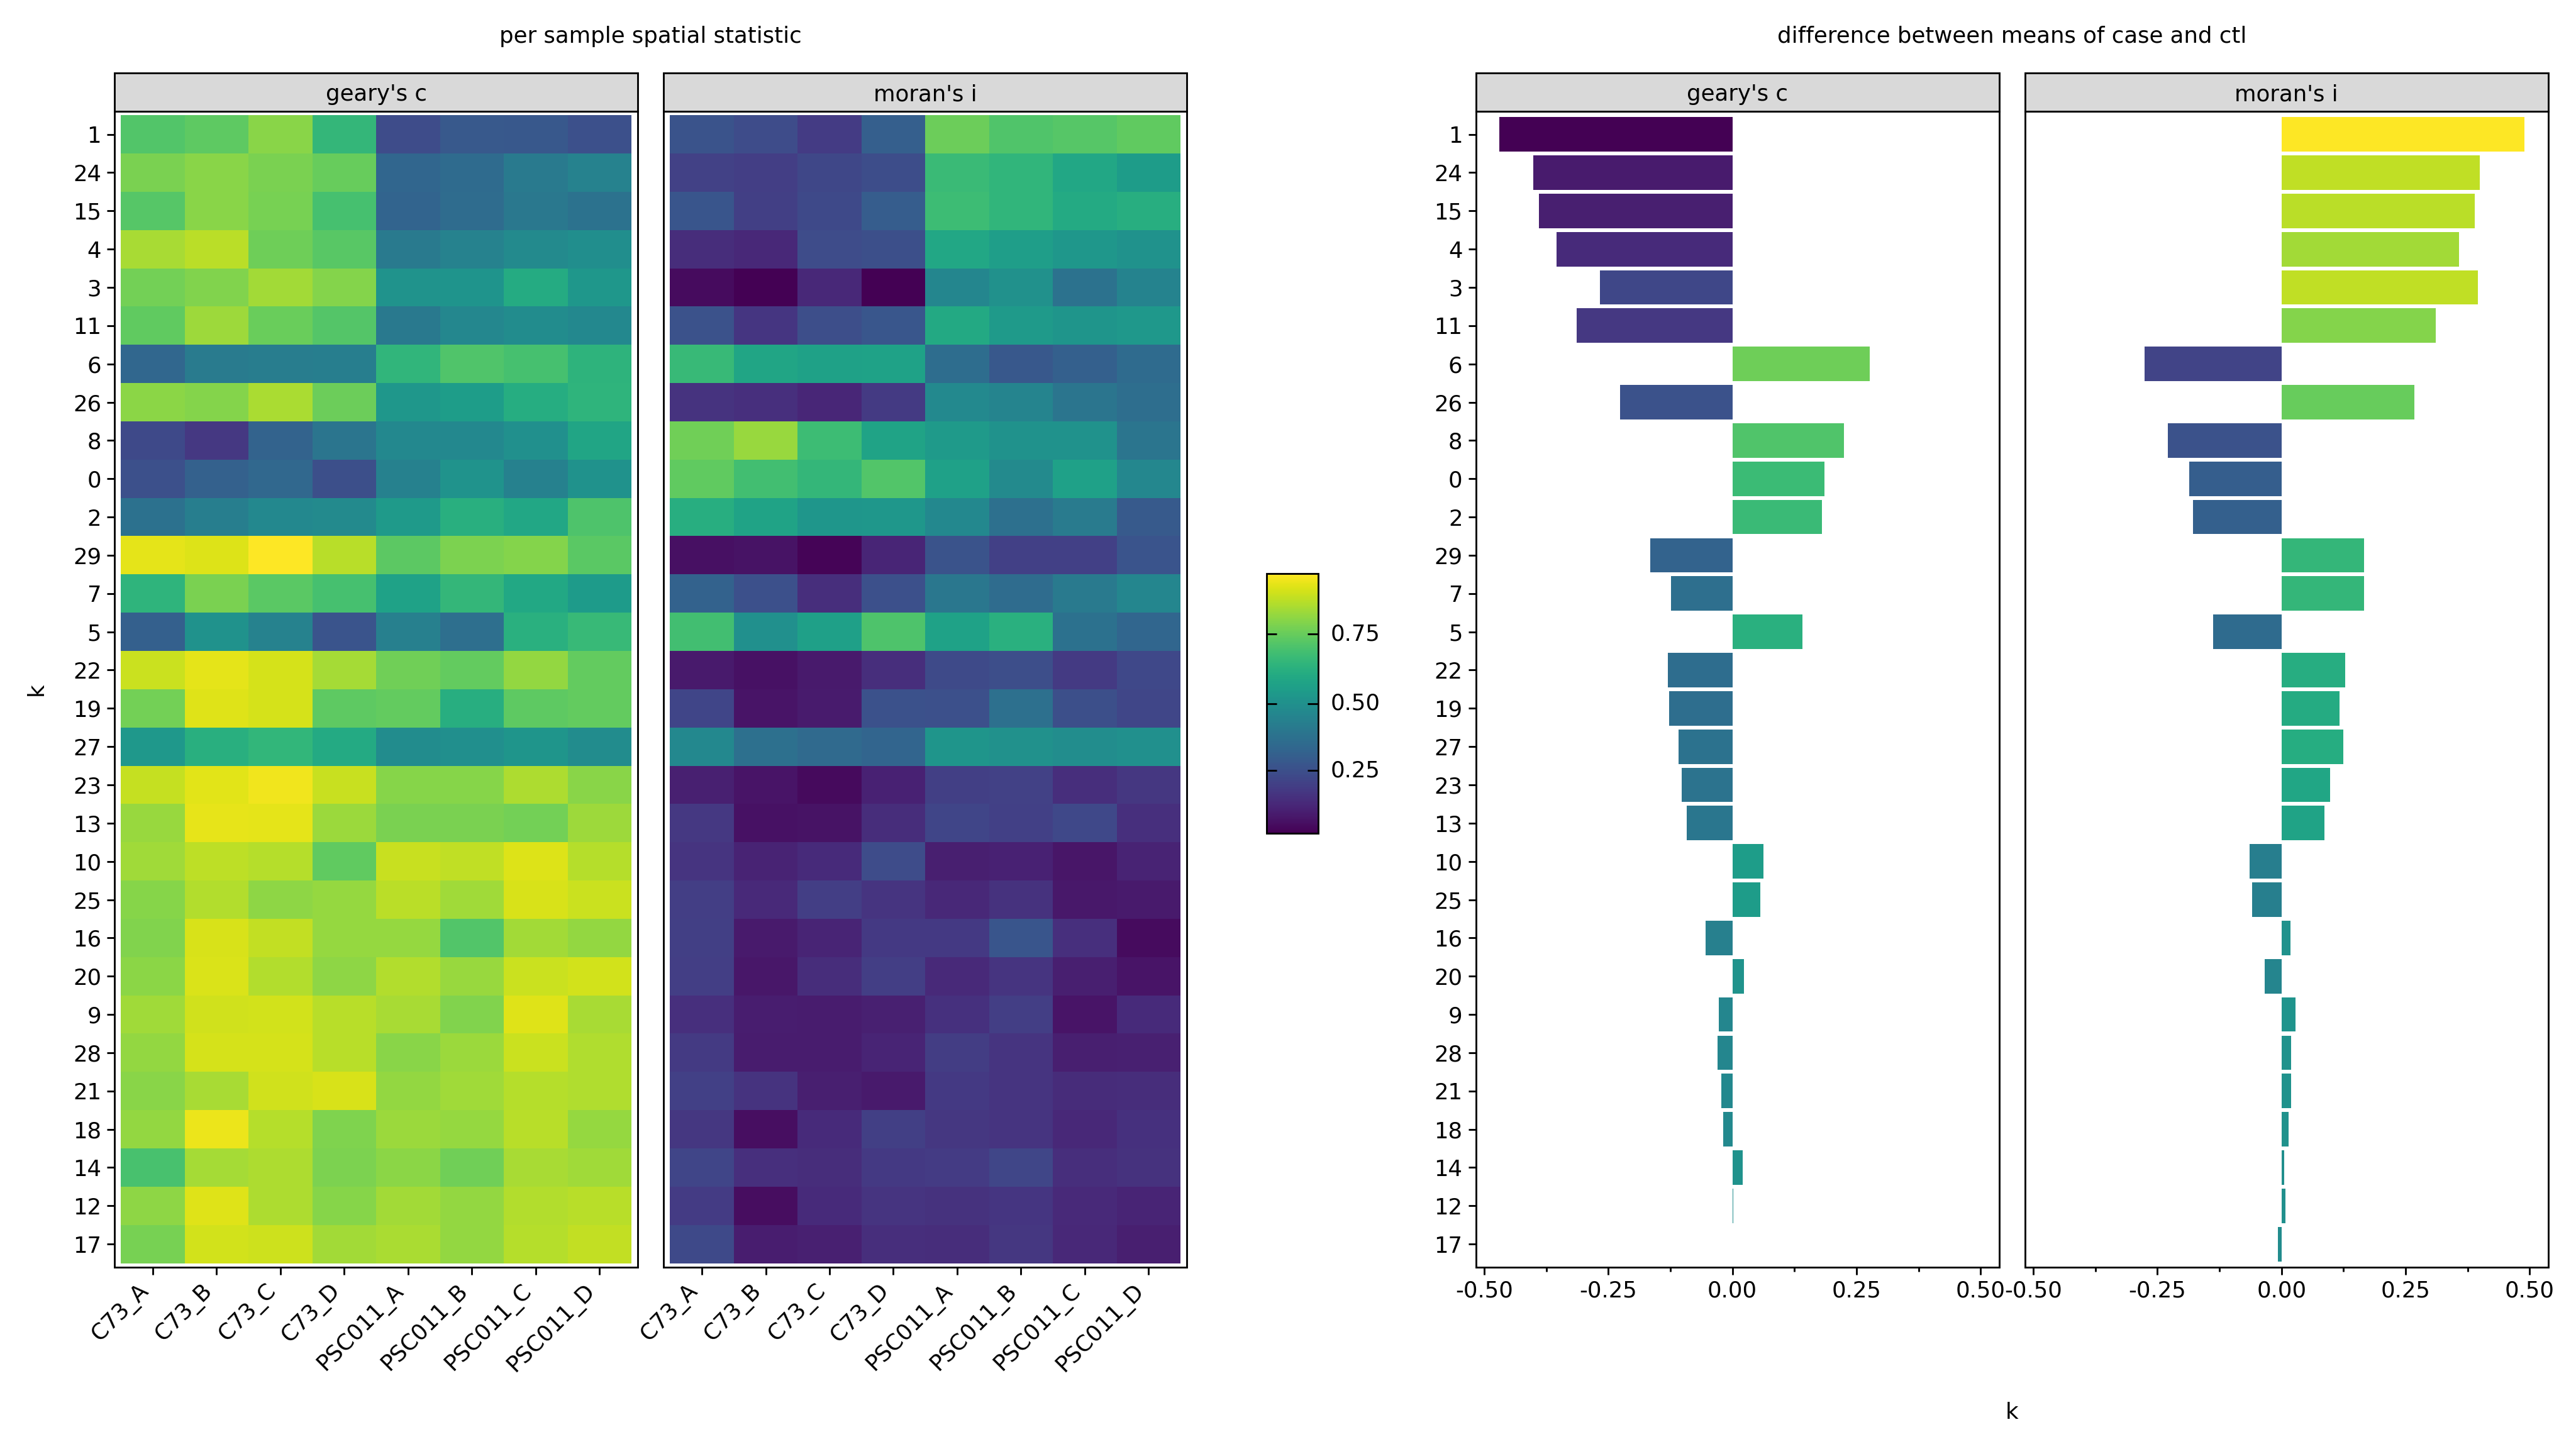

In [8]:
(sp_stat_pl & theme(figure_size=(16, 9))).show()  # ty:ignore[unsupported-operator]

we plot the spatial distributions for all case-specific factors (positive beta):

In [ ]:
for k in CASE_KS:
    for p in pl_help(psc, k).values():
        p.show()

we plot the spatial distributions for all control-specific factors (negative beta):

In [ ]:
for k in CTL_KS:
    for p in pl_help(psc, k).values():
        p.show()

to explore this further, we proceed w/ a gene-wise analysis for all case- and control-specific factors:

In [ ]:
ks_oi = CASE_KS + CTL_KS
for k in ks_oi:
    sP.run_gene_reg(psc, SP_FACT_PAT_STR.format(k=k), SP_GENE_PAT_STR.format(k=k), layer="counts", run_reg=False)

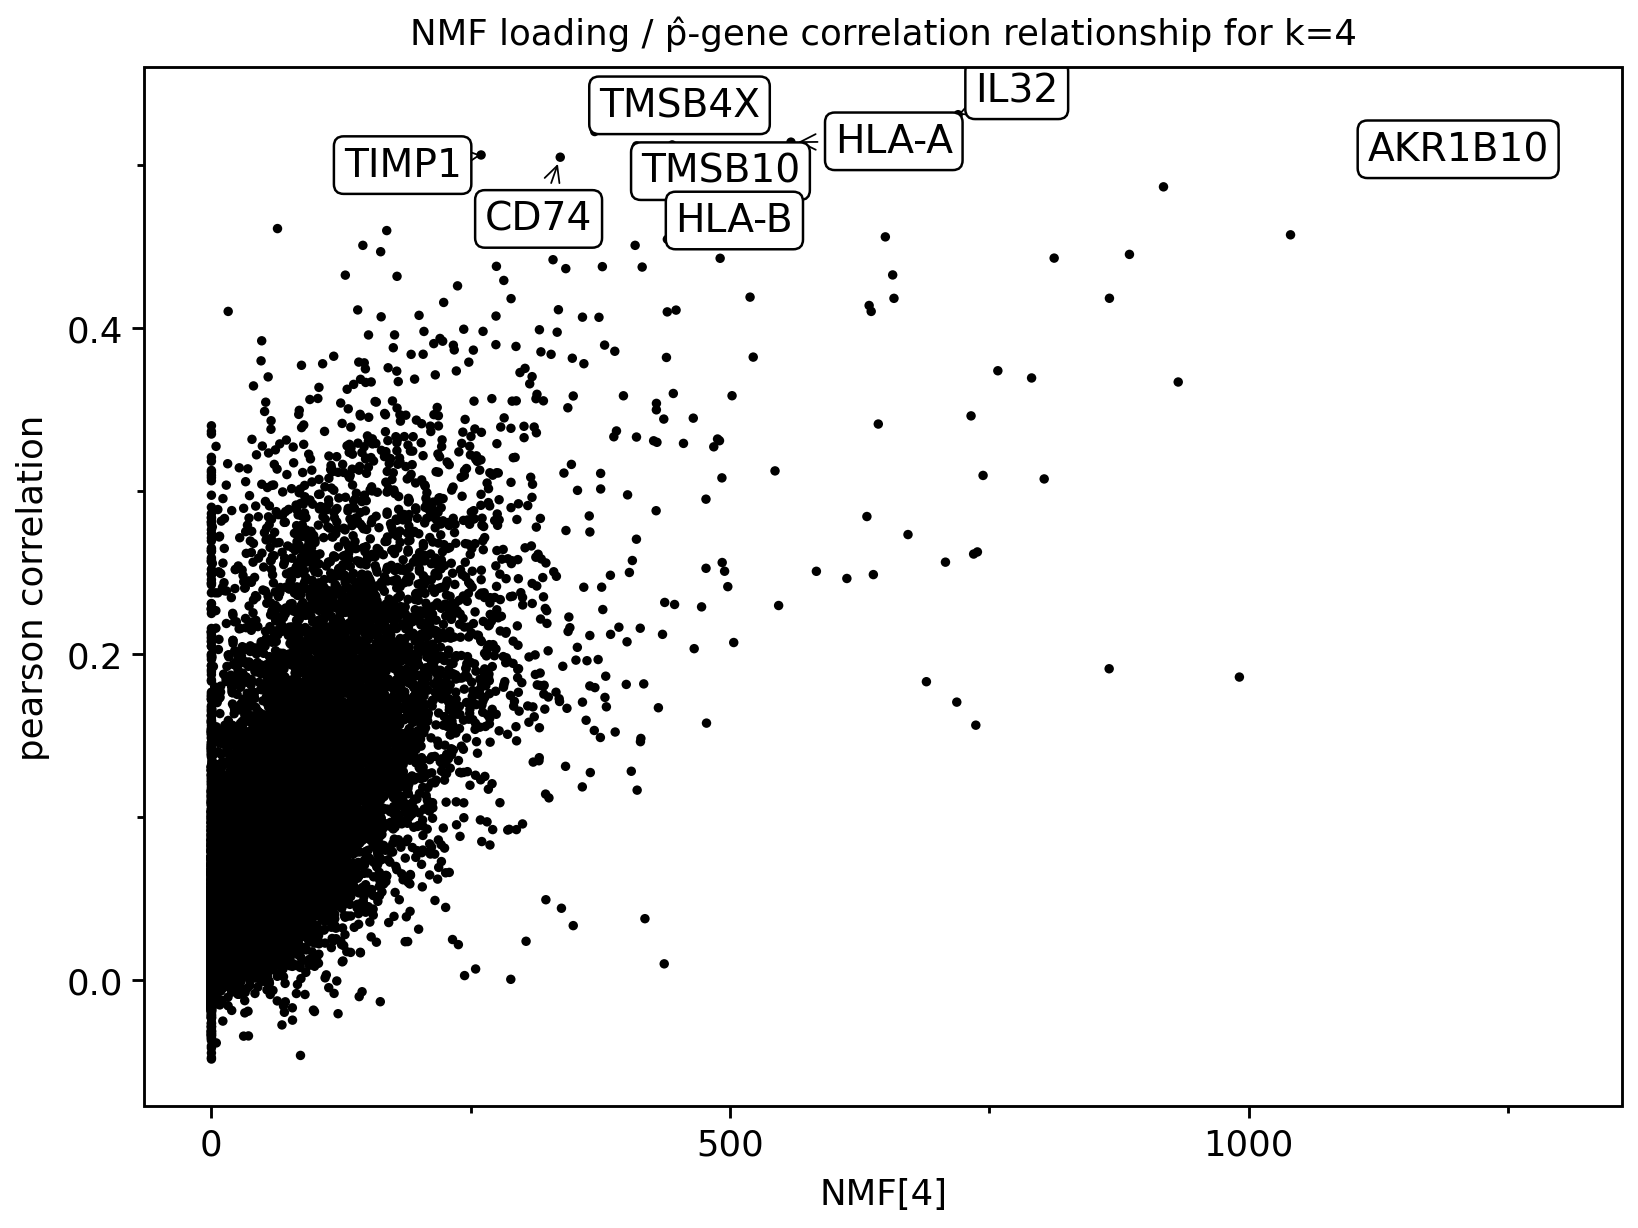

In [12]:
for k in ks_oi:
    (
        uapl.PlotAdata(psc)
        + aes(
            x=uapl.varm("X_nmf", k),
            y=uapl.varm(SP_GENE_PAT_STR.format(k=k), "corr"),
            label=np.where(
                np.argsort(np.argsort(-np.abs(np.asarray(psc.varm[SP_GENE_PAT_STR.format(k=k)]["corr"])))) < 8,
                psc.var["SYMBOL"],
                None,  # ty:ignore[invalid-argument-type]
            ),
        )
        + geom_point(size=1.5, shape="o", stroke=0)
        + geom_label(adjust_text={}, na_rm=True)
        + labs(
            colour="-log(pval)",
            x=f"NMF[{k}]",
            y="pearson correlation",
            title=f"NMF loading / p\u0302-gene correlation relationship for k={k}",
        )
    ).show()

In [13]:
degs = {k: run_deg_groups(psc, k, "group", "CTL") for k in ks_oi}
sig_sub = {k: degs[k].loc[lambda e: (e["adj_pval"] < 0.05) & (e["lfc"].abs() > 1)] for k in ks_oi}

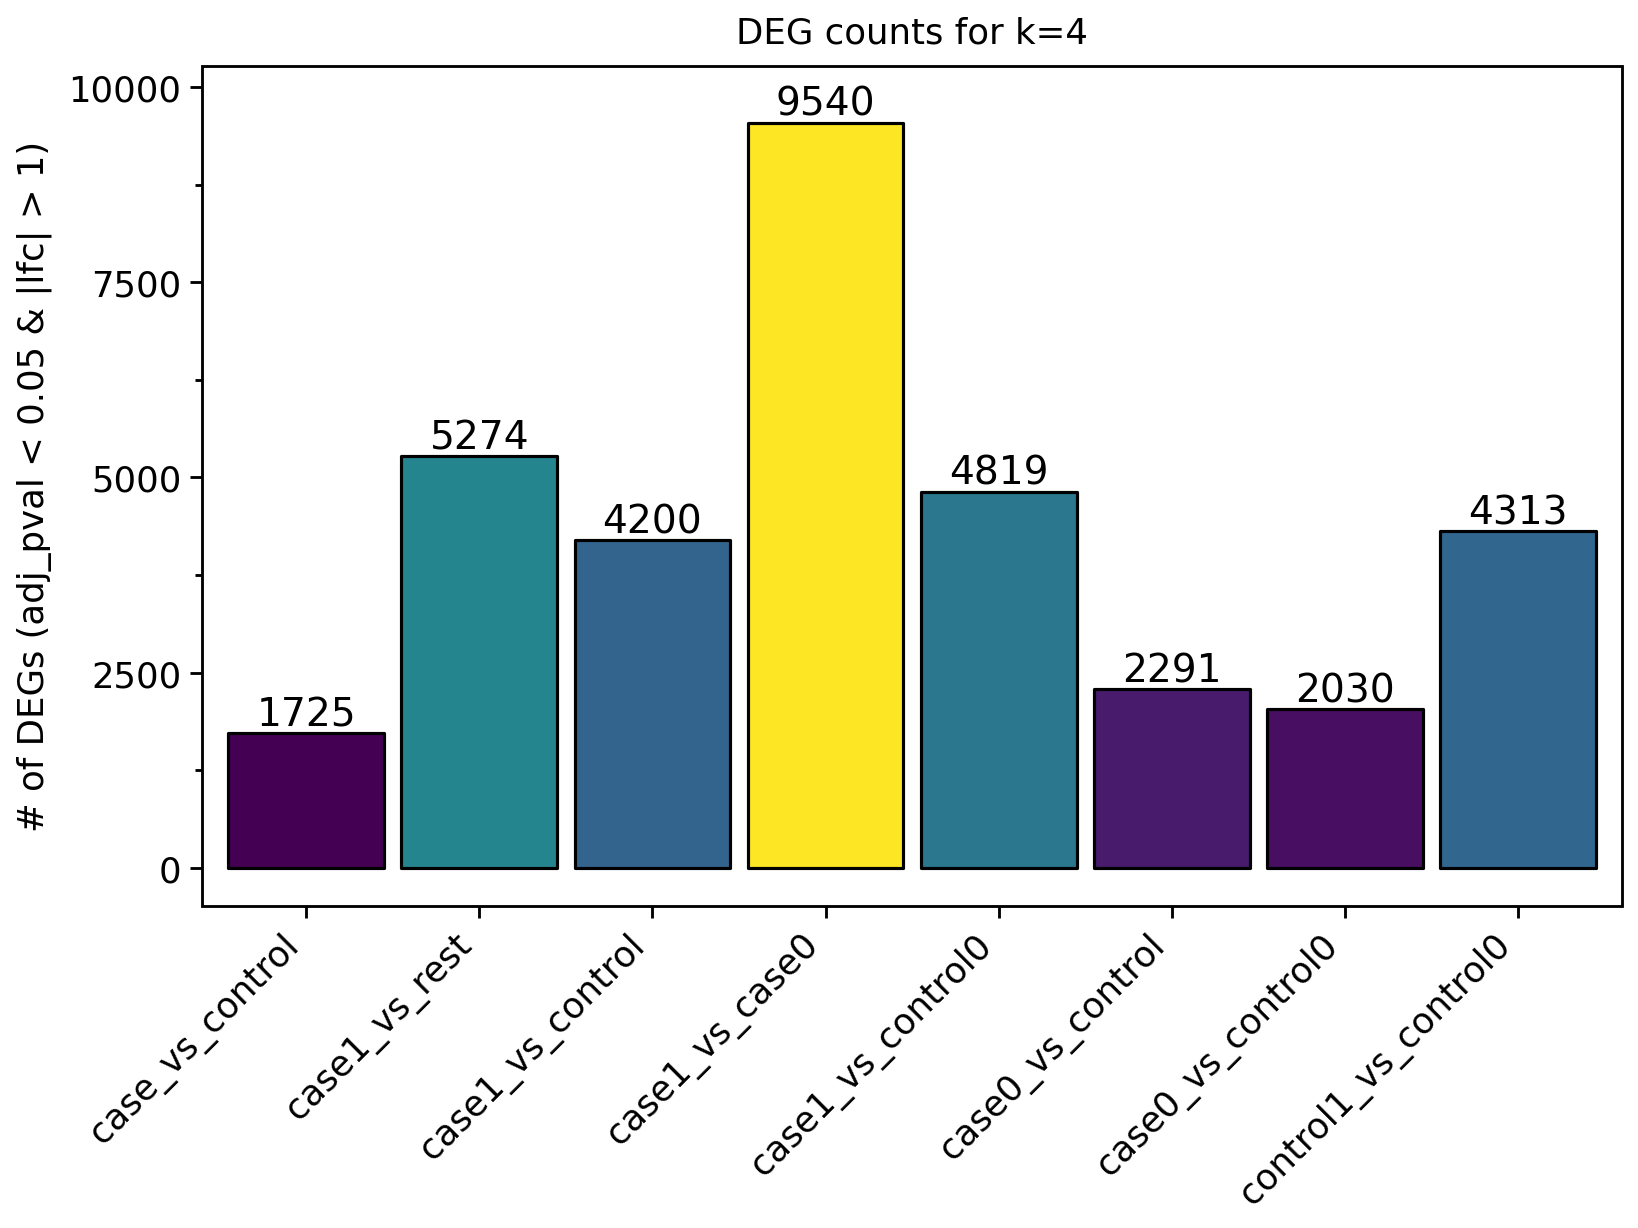

In [14]:
for k in ks_oi:
    sig_counts = sig_sub[k].groupby("cmp", observed=True)["gene"].count()
    (
        ggplot(sig_counts.reset_index(drop=False))
        + aes(x="cmp", y="gene", fill=after_stat("y"), label=after_stat("y"))
        + geom_col(color="black")
        + geom_text(nudge_y=sig_counts.max() * 0.025)
        + theme(axis_text_x=element_text(angle=45, hjust=1))
        + guides(fill="none")
        + labs(x="", y="# of DEGs (adj_pval < 0.05 & |lfc| > 1)", title=f"DEG counts for k={k}")
    ).show()

we can further visualize the permutations of gene set size in these comparisons via the upsetplot package:

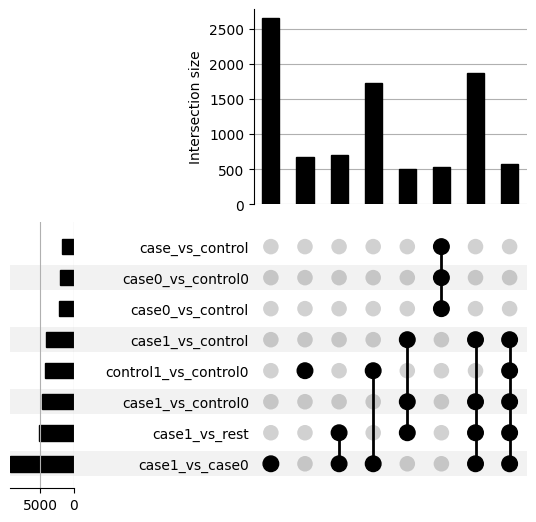

In [15]:
for k in ks_oi:
    with catch_warnings():
        simplefilter(action="ignore", category=FutureWarning)
        up.UpSet(
            up.from_contents({k: v.array for k, v in sig_sub[k].groupby("cmp", observed=True)["gene"]}),
            subset_size="count",
            max_subset_rank=8,
        ).plot()

    plt.show()